In [2]:
# Always run this before anything else

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

import pyfade

# Using the PyFaDe library

## Table of Contents:
* [1 - Introduction](#intro)
    * [1.1 - Example: rolling mean of a time-series](#intro-example)

## 1 - Introduction <a class ="anchor" id="intro">

This notebook will show how to implement and use the pyfade library. This notebook will also show how to add features and feature groups in Python.

The Python Failure Detection library (PyFaDe) is a collection of routines to extract features from time-series (one-dimensional and multi-dimensional). Among the implemented features, are the rolling statistics, matrix profile and k-dimensional profiles.

To use this library, the user must first define a time-series. Then, windows are defined, based on its size. Finally, features are added to this window. Whenever the time-series is updated, the features get automatically updated aswell. The following section shows an example.

### 1.1 - Example: rolling mean of a time-series <a class ="anchor" id="intro-example">

The following code shows how to setup the library to calculate the rolling mean of the following time-series:

$$f[n] = sin(0.5 * n)$$

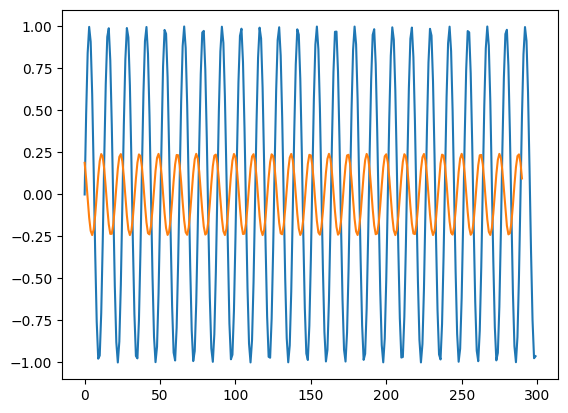

In [3]:
N = 300
n = np.arange(N,dtype=float)

y = np.sin(n*0.5)

# Defining the dataset object
builder = pyfade.DataFrameBuilder(y)
dataset = builder.build()

# Creating the window
WINDOW_SIZE = 10
window_builder = pyfade.WindowBuilder(dataset)
window_builder.set_window_size(WINDOW_SIZE)
window = window_builder.build()

# Adding the feature
feature_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.ContinuousStatistics,window)
feature_builder.build()

plt.plot(dataset.data.T);

plt.plot(window.mean.T);


The general workflow of this package is as follows:

First, we create a DataFrame object, using a DataFrameBuilder. This is initialized by:

```
builder = pyfade.DataFrameBuilder(<numpy_or_pandas_dataset>)
```

Some properties, such as interpolator or decomposition can be set from this builder, for example:

```
builder.set_interpolation(pf.Interpolation.LINEAR)
```


Additional properties are shown in Section [2.1](#dataframe-builder). Finally, the DataFrame is build with:

```
builder.build()
```

For the Window object, we use the same procedure. First, we create it by giving the dataset and the window size:

```
window_builder = pyfade.WindowBuilder(dataset)
window_builder.set_window_size(WINDOW_SIZE)
```

In the end, we build it:

```
window_builder.build()
```

Note that setting the window size is REQUIRED. An error will be raised otherwise.

Finally, feature groups can be added to this window with a FeatureGroupBuilder object:

```
feature_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.ContinuousStatistics,window)
```

pyfade.FeatureGroups is an Enum with all Feature Groups. And then building it:

```
feature_builder.build()
```



## 1.2 - Running batch vs real-time

This package automatically updates the data in Window objects whenever the DataFrame is changed. This allows for real-time analyses.



Text(0.5, 1.0, 'Real-time study')

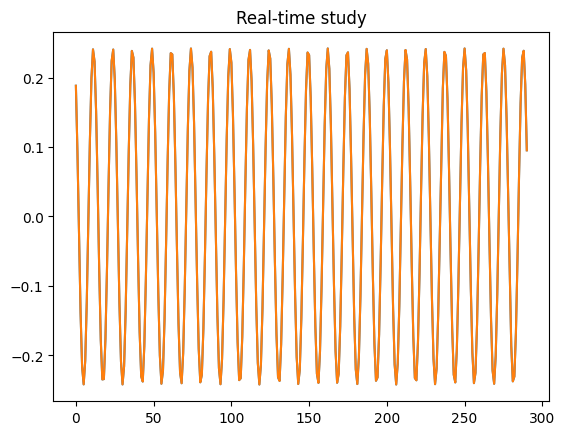

In [ ]:
WINDOW_SIZE = 10
def example_dataset(data:np.ndarray):
    builder = pyfade.DataFrameBuilder(data)
    dataset = builder.build()

    # Creating the window
    window_builder = pyfade.WindowBuilder(dataset)
    window_builder.set_window_size(WINDOW_SIZE)
    window = window_builder.build()

    # Adding the feature
    feature_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.ContinuousStatistics,window)
    feature_builder.build()

    return dataset, window


N = 300
n = np.arange(N,dtype=float)

y = np.sin(n*0.5)

# Defining the dataset object
dataset, window = example_dataset(y)

plt.plot(window.mean.T);
plt.title("Batch study")


# Defining the dataset object
start = 20
update_size = 5
dataset, window = example_dataset(y[:start])

end = start + update_size
while end < y.size:
    dataset.insert_data(y[start:end])
    start = end
    end = start + update_size
end = y.size
dataset.insert_data(y[start:end])

# plt.figure()
plt.plot(window.mean.T);
plt.title("Real-time study")

## 2 - DataFrameBuilder Class <a class="anchor" id="dataframe-builder">

The DataFrameBuilder is a Builder class that creates DataFrame objects.


The following sections will detail the methods and parameters from this class.

### 2.1 - Methods <a class="anchor" id="dataframe-builder-methods">

 All setup methods can be applied with method chaining, that is:

```
dataset = 
pyfade.DataFrameBuilder(<dataset>).set_interpolation(<interpolation_method>).set_extrapolation(<extrapolation_method>).build()
```

#### 2.1.1 - build()

Returns the DataFrame object that has been build by this Builder object.

```
Inputs: None
```

```
Returns: DataFrame
```

```
Raises: RuntimeError if the dataset is not set before calling this method.
```


#### 2.1.2 - set_interpolation(Interpolation)

Sets up the interpolation method in the Interpolator object (see Section [?])

```
Inputs: pyfade.Interpolation (enum of interpolation methods)
```

```
Returns: Self (for method chaining)
```



#### 2.1.3 - set_extrapolation(Extrapolation)

Sets up the extrapolation method in the Extrapolation object (see Section [?])

```
Inputs: pyfade.Extrapolation (enum of extrapolation methods)
```

```
Returns: Self (for method chaining)
```


#### 2.1.4 - add_cleaner()



## 3 - DataFrame Class <a class="anchor" id="dataframe">

DataFrame defines the object that holds the dataset and that runs the corresponding algorithms on the dataset itself, such as interpolation.

Data can be appended during runtime through this object. All windows are automatically notified of this and run their update routines (Section [?]).

Most of the raw data is held in C++. This object manages the interface between both languages.

### 3.1 - Attributes

#### 3.1.1 - dataset: pyDataSet

This is the main attribute of the class, that holds the dataset.

pyDataSet is a class defined in Python that inherits the C++ DataSet class (See /include/cfade/dataset/dataset.h). This C++ class inherits from DataSetObservable a notify() method, responsible for notifying implementations of IDataSetObserver, such as Window, following an Observer design pattern implementation.

This attribute should not be directly called by the user, as most of its attributes are already callable by the DataFrame object itself. However, it has the following readonly properties

See Section [?] for more details.


### 3.1.2 - interpolator: InterpolatorInterface

This holds an implementation of InterpolatorInterface (Section [?]) responsible for running the interpolation and extrapolation methods each time the data is changed.

Note that the interpolation and extrapolation methods are run on the entire data each time it is changed. Thus, a data point that was previously extrapolated on, may be now interpolated on.

### 3.2 - Properties

#### 3.2.1 - data: numpy.ndarray

This property is related to the data attribute from dataset.

The getter returns the numpy array.

The setter sets up the given array as the dataset array.

#### 3.2.2 - index: numpy.ndarray

This property corresponds to the index of each timestamp. Especially important when the data is a pandas Series or pandas DataFrame.

### 3.3 - Methods

## 4 - 


```
len: int - number of timestamps in the time-series.
ndim: int - number of dimensions in the time-series.
shape: (int,int) - tuple containing (dim,len).
```

The following property:

```
data: numpy_array<double> - the time series (column-major array).
```

The following methods:

```
insert_data(numpy_array<double>) - appends the new data to the data array and notify observers.
add_observer(IDataSetObserver*) - Includes new observer (Inherited from DataSetObservable).
remove_observer(IDataSetObserver*) - Removes the observer (Inherited from DataSetObservable).
```

